In [65]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import imutils

(np.float64(-0.5), np.float64(474.5), np.float64(266.5), np.float64(-0.5))

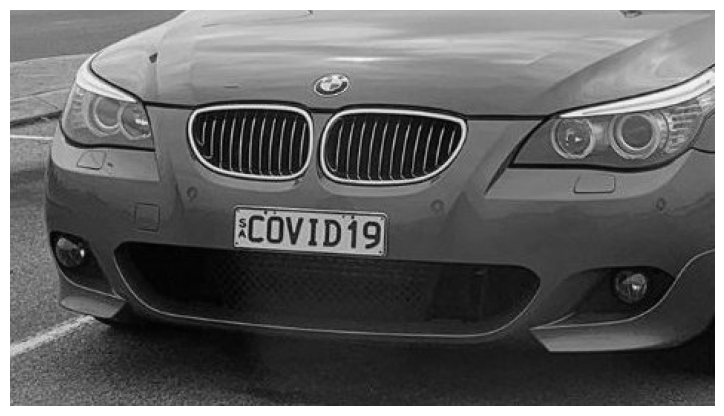

In [66]:
img = cv2.imread("image2.jpg")  
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.axis("off")


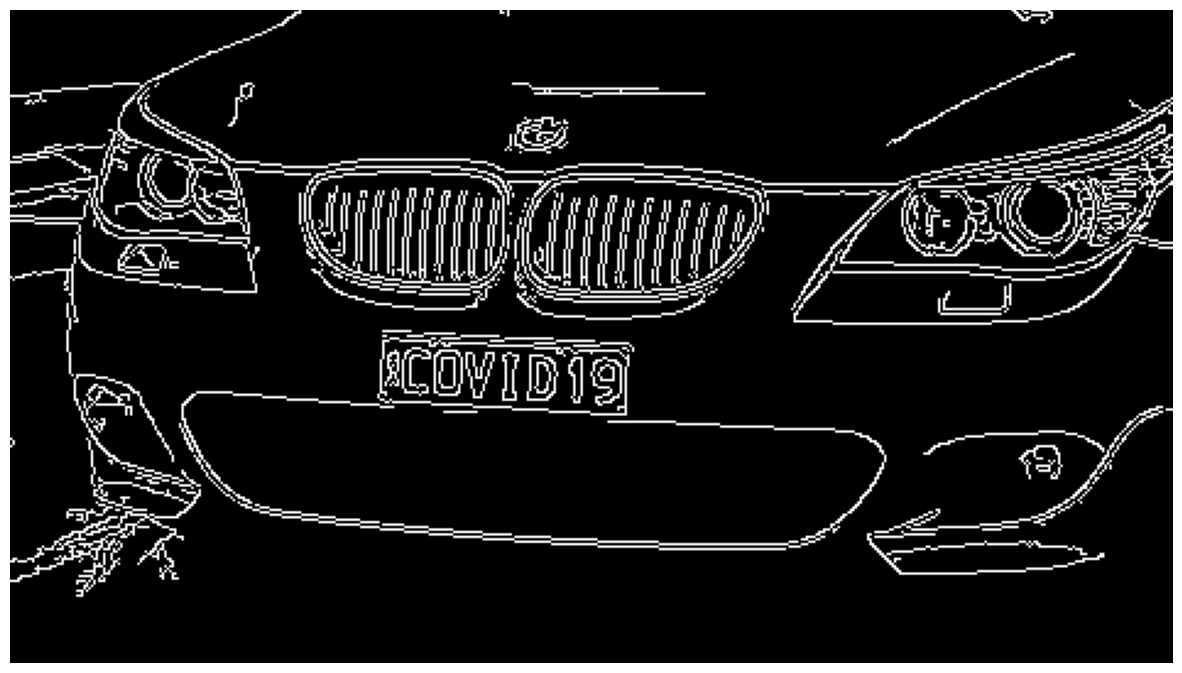

In [67]:
bfilter = cv2.bilateralFilter(gray, 11,17,17)
edged = cv2.Canny(bfilter, 30, 200)
plt.figure(figsize=(15,10))
plt.imshow(edged, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(474.5), np.float64(266.5), np.float64(-0.5))

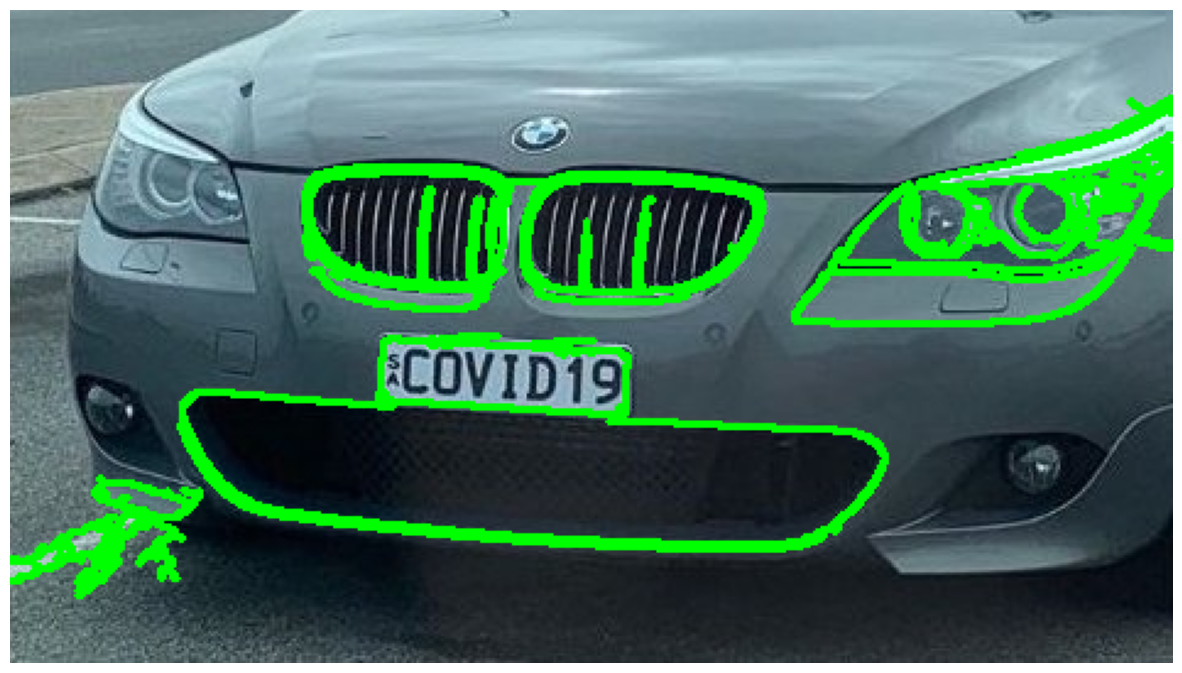

In [68]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

img_contours = img.copy()    

plt.figure(figsize=(15,10))
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)
plt.imshow(img_contours[:, :, ::-1])
plt.axis("off")

In [69]:
location = None
for contour in contours:
  epsilon = 0.02 * cv2.arcLength(contour, True)
  approx = cv2.approxPolyDP(contour, epsilon , True)

  if len(approx) == 4:
    location= approx   
    break


In [70]:
location

array([[[152, 136]],

       [[248, 139]],

       [[251, 164]],

       [[153, 160]]], dtype=int32)

In [71]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], 0, 255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

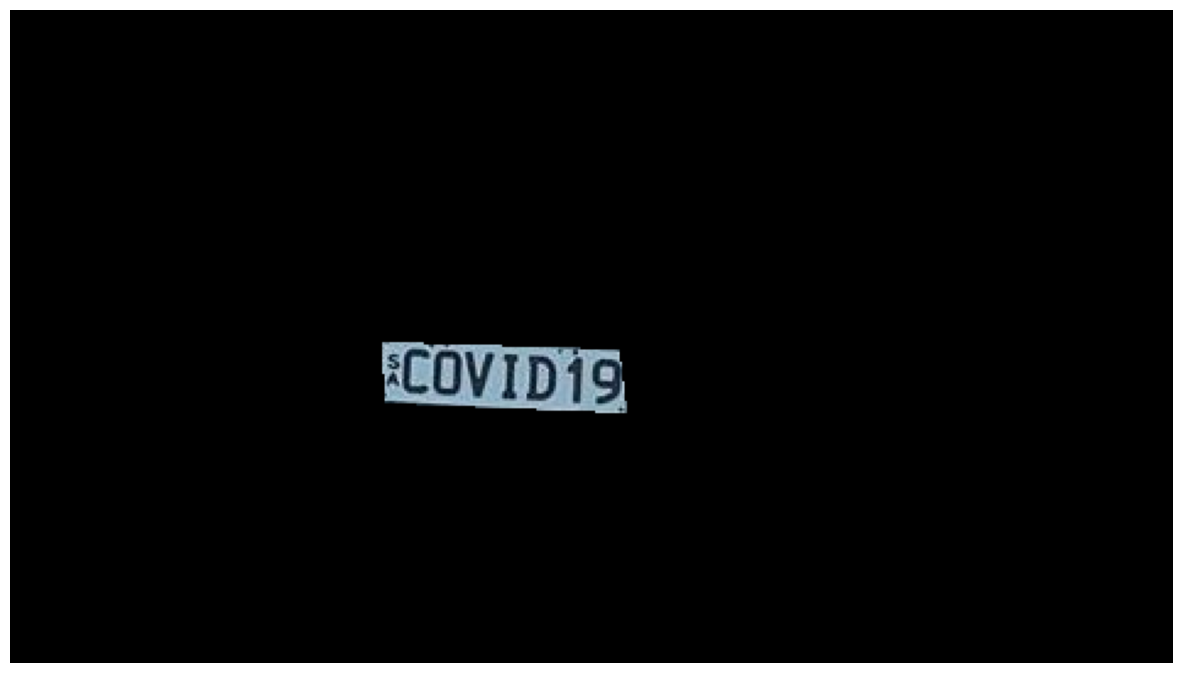

In [72]:
plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [73]:
(x,y) = np.where(mask==255)
(x1, y1) = (np.min(x), np.min(y))
(x2, y2) = (np.max(x), np.max(y))
cropped_image = gray2[x1:x2+1, y1:y2+1]
_,cropped_binaria = cv2.threshold(cropped_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

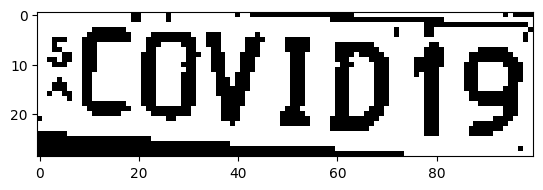

In [74]:
plt.imshow(cv2.cvtColor(cropped_binaria, cv2.COLOR_BGR2RGB))